In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf

In [ ]:
x1 = tf.constant(5)
x2 = tf.constant(6)
x3 = tf.add(x1,x2)
print(x3)

tf.Tensor(11, shape=(), dtype=int32)


In [ ]:
v1 = tf.constant([1, 2, 3, 4])
v2 = tf.constant([5, 6, 7, 8])
v3= v1 + v2
print(v3)

tf.Tensor([ 6  8 10 12], shape=(4,), dtype=int32)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
data = pd.read_csv('/content/FuelConsumptionCo2.csv')
data.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
x_data = data.loc [:,'ENGINESIZE'].values
y_data = data.loc [:,'CO2EMISSIONS'].values

In [ ]:
x = tf.constant(x_data, name='x')
y = tf.constant(y_data, name='y')
w = tf.Variable(2.0, name='w')
b = tf.Variable(7.2, name='b')



In [ ]:
def H(x):
  y_pred = w*x+b
  return y_pred

In [ ]:
def const_func(y_actual, y_pred):
  mse = tf.reduce_mean(tf.square(y_actual-y_pred))
  return mse

In [ ]:
lr = 0.01
epochs = 100
losses_values = []
for epoch in range(epochs):
  with tf.GradientTape() as tap:
    x_casted = tf.cast(x, tf.float32)
    y_casted = tf.cast(y, tf.float32)

    y_pred = H(x_casted)
    loss = const_func(y_casted, y_pred)
    losses_values.append(loss)
    gradients = tap.gradient(loss, [w,b])
    w.assign_sub(lr*gradients[0])
    b.assign_sub(lr*gradients[1])

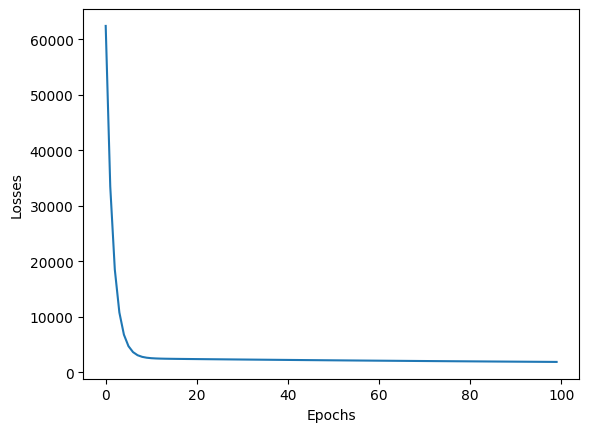

In [ ]:
plt.plot(losses_values)
plt.xlabel('Epochs')
plt.ylabel('Losses')
plt.show()

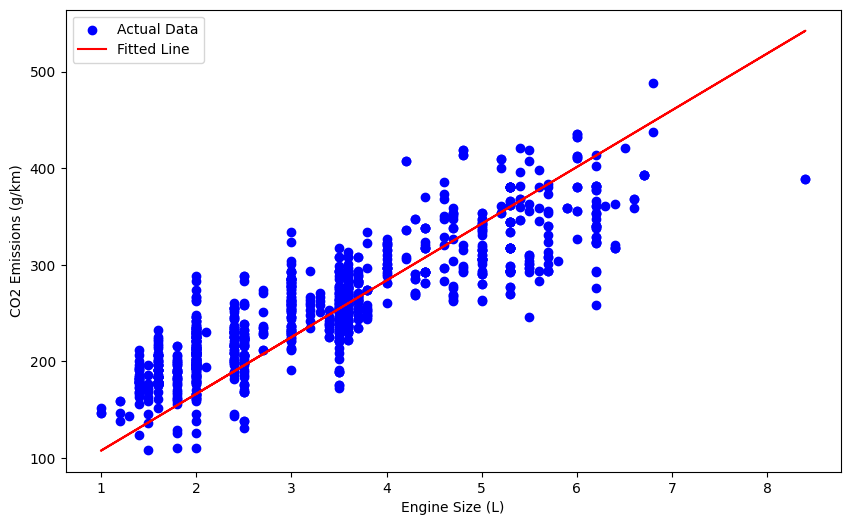

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x.numpy(), y.numpy(), color='blue', label='Actual Data')
plt.plot(x.numpy(), w * x.numpy() + b, color='red', label='Fitted Line')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [ ]:
data = pd.read_csv('/content/FuelConsumptionCo2.csv')
data = pd.get_dummies(data, drop_first=True)
x = data.iloc[:,:-1].values
y = data.iloc[:,-1].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

model = Sequential()
model.add(Dense(32, activation='sigmoid', input_shape=(x.shape[1],)))
model.add(Dense(16, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(1))
model.summary()
#model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │        23,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,613 (96.14 KB)

 Trainable params: 24,613 (96.14 KB)

 Non-trainable params: 0 (0.00 B)